# Assignment 2: Urban Flooding Modeling

Tatar Anurakwongsri

9/28/2026

## 1. Download DEM data

In [3]:
# Import Libraries

# Download DEM files
import requests
import os, os.path

# HAND Model
import numpy as np
import pysheds
from pysheds.grid import Grid
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import rasterio as rio
from rasterio.plot import show

# Mosaic
import fiona
import glob
from rasterio.merge import merge
from shapely.geometry import Polygon
from shapely.geometry import shape

In [7]:
def get_tile_name(lat, lon):
    """
    Returns the USGS tile name formatted correctly (e.g., 'n39w076').
    """
    lat_tile = f"n{int(abs(lat)):02d}" if lat >= 0 else f"s{int(abs(lat)):02d}"
    lon_tile = f"w{int(abs(lon)):03d}" if lon < 0 else f"e{int(abs(lon)):03d}"
    return f"{lat_tile}{lon_tile}"

In [8]:
def get_tiles_in_bbox(min_lat, max_lat, min_lon, max_lon):
    """
    Returns a list of tile names covering a bounding box.
    """
    tile_list = []
    for lat in range(int(min_lat), int(max_lat) + 1):
        for lon in range(int(min_lon), int(max_lon) + 1):
            tile_list.append(get_tile_name(lat, lon))
    return tile_list

In [9]:
def download_dem_1arc(tile_name, save_path="."):
    """
    Downloads a 1-arc-second (~30m) DEM tile from USGS TNM.
    
    Parameters:
        tile_name (str): Tile name (e.g., "n39w076").
        save_path (str): Directory to save the DEM file.
    """
    base_url = "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1/TIFF/current"
    url = f"{base_url}/{tile_name}/USGS_1_{tile_name}.tif"
    
    output_file = os.path.join(save_path, f"{tile_name}.tif")
    
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(output_file, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"✅ DEM Tile {tile_name} downloaded successfully!")
    else:
        print(f"❌ Error: Tile {tile_name} not found. Check availability.")
        print(url)
# Download multiple tiles
save_directory = "DEM_tiles"
os.makedirs(save_directory, exist_ok=True)  # Create folder if it doesn't exist

# https://observablehq.com/@rdmurphy/u-s-state-bounding-boxes
tiles = get_tiles_in_bbox(39.720265072840725, 42.269954234532335, -80.52071966199662, -74.69529551145511)

for tile in tiles:
    download_dem_1arc(tile, save_directory)

✅ DEM Tile n39w080 downloaded successfully!
✅ DEM Tile n39w079 downloaded successfully!
✅ DEM Tile n39w078 downloaded successfully!
✅ DEM Tile n39w077 downloaded successfully!
✅ DEM Tile n39w076 downloaded successfully!
✅ DEM Tile n39w075 downloaded successfully!
❌ Error: Tile n39w074 not found. Check availability.
https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1/TIFF/current/n39w074/USGS_1_n39w074.tif
✅ DEM Tile n40w080 downloaded successfully!
✅ DEM Tile n40w079 downloaded successfully!
✅ DEM Tile n40w078 downloaded successfully!
✅ DEM Tile n40w077 downloaded successfully!
✅ DEM Tile n40w076 downloaded successfully!
✅ DEM Tile n40w075 downloaded successfully!
❌ Error: Tile n40w074 not found. Check availability.
https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1/TIFF/current/n40w074/USGS_1_n40w074.tif
✅ DEM Tile n41w080 downloaded successfully!
✅ DEM Tile n41w079 downloaded successfully!
✅ DEM Tile n41w078 downloaded successfully!
✅ DEM Tile n41w077 downloaded succ

## 2. Compute the height above nearest drainage for all tiles

### Compute the flow directions, accumulation, HAND, and inundation depth for a given DEM

In [10]:
dem_path = 'DEM_tiles'
dem_list = []
output_list = []

for file in os.listdir(dem_path):    
    if file.endswith('.tif'):
        dem_tile = os.path.join(dem_path, file)
        dem_list.append(dem_tile)
print('The number of tiles is:', len(dem_list))

# Specify directional mapping
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
threshold = 3

for tile in dem_list:
    grid = Grid.from_raster(tile)
    dem = grid.read_raster(tile)
    
    pit_filled_dem = grid.fill_pits(dem)                # Fill pits in DEM
    flooded_dem = grid.fill_depressions(pit_filled_dem) # Fill depressions in DEM
    inflated_dem = grid.resolve_flats(flooded_dem)      # Resolve flats in DEM
    
    fdir = grid.flowdir(inflated_dem, dirmap=dirmap)    # Compute flow directions
    acc = grid.accumulation(fdir, dirmap=dirmap)        # Calculate flow accumulation
    hand = grid.compute_hand(fdir, dem, acc > 200)      # Compute height above nearest drainage with accumulation > 200

    
    hand_view = grid.view(hand, nodata=np.nan)          # Create a view of HAND in the catchment
    inundation_extent = np.where(hand_view < threshold, threshold - hand_view, np.nan)  # if the hand value is larger than threshold, then use nan

    output_list.append((tile, inundation_extent))
    print(f'Calculated Inundation for {tile}')

The number of tiles is: 27
Calculated Inundation for DEM_tiles\n38w076.tif
Calculated Inundation for DEM_tiles\n39w075.tif
Calculated Inundation for DEM_tiles\n39w076.tif
Calculated Inundation for DEM_tiles\n39w077.tif
Calculated Inundation for DEM_tiles\n39w078.tif
Calculated Inundation for DEM_tiles\n39w079.tif
Calculated Inundation for DEM_tiles\n39w080.tif
Calculated Inundation for DEM_tiles\n40w075.tif
Calculated Inundation for DEM_tiles\n40w076.tif
Calculated Inundation for DEM_tiles\n40w077.tif
Calculated Inundation for DEM_tiles\n40w078.tif
Calculated Inundation for DEM_tiles\n40w079.tif
Calculated Inundation for DEM_tiles\n40w080.tif
Calculated Inundation for DEM_tiles\n41w074.tif
Calculated Inundation for DEM_tiles\n41w075.tif
Calculated Inundation for DEM_tiles\n41w076.tif
Calculated Inundation for DEM_tiles\n41w077.tif
Calculated Inundation for DEM_tiles\n41w078.tif
Calculated Inundation for DEM_tiles\n41w079.tif
Calculated Inundation for DEM_tiles\n41w080.tif
Calculated In

## 3. Export the result as GEOTIFF

In [15]:
GEOTIFF_path = 'GEOTIFF_tiles'
os.makedirs(GEOTIFF_path, exist_ok=True)

for (tile, inundation_extent) in output_list:
    tile_name   = os.path.splitext(os.path.basename(tile))[0]
    outfilename = os.path.join(GEOTIFF_path, tile_name + ".tif")
    
    with rio.open(tile) as src:
        meta = src.meta.copy()
        meta.update(dtype=rio.float32, compress='lzw', nodata=np.nan)
    
    with rio.open(outfilename, 'w', **meta) as dst:
        dst.write(inundation_extent.astype(np.float32), 1)

    print(f'Exported {outfilename} as GEOTIFF')

Exported GEOTIFF_tiles\n38w076.tif as GEOTIFF
Exported GEOTIFF_tiles\n39w075.tif as GEOTIFF
Exported GEOTIFF_tiles\n39w076.tif as GEOTIFF
Exported GEOTIFF_tiles\n39w077.tif as GEOTIFF
Exported GEOTIFF_tiles\n39w078.tif as GEOTIFF
Exported GEOTIFF_tiles\n39w079.tif as GEOTIFF
Exported GEOTIFF_tiles\n39w080.tif as GEOTIFF
Exported GEOTIFF_tiles\n40w075.tif as GEOTIFF
Exported GEOTIFF_tiles\n40w076.tif as GEOTIFF
Exported GEOTIFF_tiles\n40w077.tif as GEOTIFF
Exported GEOTIFF_tiles\n40w078.tif as GEOTIFF
Exported GEOTIFF_tiles\n40w079.tif as GEOTIFF
Exported GEOTIFF_tiles\n40w080.tif as GEOTIFF
Exported GEOTIFF_tiles\n41w074.tif as GEOTIFF
Exported GEOTIFF_tiles\n41w075.tif as GEOTIFF
Exported GEOTIFF_tiles\n41w076.tif as GEOTIFF
Exported GEOTIFF_tiles\n41w077.tif as GEOTIFF
Exported GEOTIFF_tiles\n41w078.tif as GEOTIFF
Exported GEOTIFF_tiles\n41w079.tif as GEOTIFF
Exported GEOTIFF_tiles\n41w080.tif as GEOTIFF
Exported GEOTIFF_tiles\n42w074.tif as GEOTIFF
Exported GEOTIFF_tiles\n42w075.tif

## 4. Mosaic results into one GEOTIFF of Pennsylvania

In [17]:
GEOTIFF_path = 'GEOTIFF_tiles'
outfile = 'pennsylvania_HAND.tif'

# start to mosaic the raster tiles
tiflist = []

for file in os.listdir(GEOTIFF_path):    
    if file.endswith('.tif'):
        tiffile = os.path.join(GEOTIFF_path, file)
        tiflist.append(tiffile)

src_files_to_mosaic = []
for fp in tiflist:
    try:
        tile_src = rio.open(fp)
        tile_bounds = tile_src.bounds
        
        src_files_to_mosaic.append(tile_src)
    except:
        continue

mosaic, out_trans = merge(src_files_to_mosaic) #, method='max'
print('You have mosaiced the results')

out_meta = tile_src.meta.copy()
out_meta.update({"driver": "GTiff",
                  "height": mosaic.shape[1],
                  "width": mosaic.shape[2],
                  "transform": out_trans, 
                  "compress": 'lzw',
                  'BIGTIFF': 'YES'
                  }
               )

#out_fp = os.path.join(dirpath, 'atlanta-naip.tif')
with rio.open(outfile, "w", **out_meta) as dest:
     dest.write(mosaic)

You have mosaiced the results


In [2]:
DEM_path = 'DEM_tiles'
outfile = 'pennsylvania_DEM.tif'

# start to mosaic the raster tiles
tiflist = []

for file in os.listdir(DEM_path):    
    if file.endswith('.tif'):
        tiffile = os.path.join(DEM_path, file)
        tiflist.append(tiffile)

src_files_to_mosaic = []
for fp in tiflist:
    try:
        tile_src = rio.open(fp)
        tile_bounds = tile_src.bounds
        
        src_files_to_mosaic.append(tile_src)
    except:
        continue

mosaic, out_trans = merge(src_files_to_mosaic) #, method='max'
print('You have mosaiced the results')

out_meta = tile_src.meta.copy()
out_meta.update({"driver": "GTiff",
                  "height": mosaic.shape[1],
                  "width": mosaic.shape[2],
                  "transform": out_trans, 
                  "compress": 'lzw',
                  'BIGTIFF': 'YES'
                  }
               )

#out_fp = os.path.join(dirpath, 'atlanta-naip.tif')
with rio.open(outfile, "w", **out_meta) as dest:
     dest.write(mosaic)

You have mosaiced the results


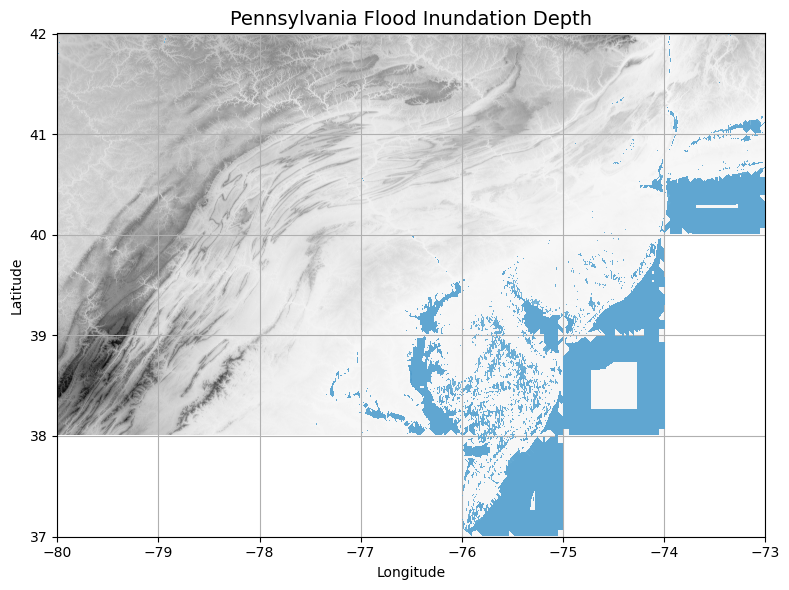

In [7]:
# Plot Pennsylvania Inundation
with rio.open('pennsylvania_HAND.tif') as src:
    inundation  = src.read(1).astype(float)   # read band 1
    nodata      = src.nodata                   # -9999
    extent      = [src.bounds.left,            # [left, right, bottom, top]
                   src.bounds.right,           # for imshow extent
                   src.bounds.bottom,
                   src.bounds.top]
    crs         = src.crs
inundation[inundation == nodata] = np.nan

with rio.open('pennsylvania_dem.tif') as src:
    dem_view = src.read(1).astype(float)
    dem_view[dem_view == src.nodata] = np.nan

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)

ax.imshow(
    dem_view,
    extent = extent,
    cmap   = 'Greys',
    aspect = 'auto',
    zorder = 1
)

ax.imshow(
    inundation,
    extent = extent,
    cmap   = 'Blues',
    vmin = -5,
    vmax = 10,
    aspect = 'auto',
    zorder = 2
)

plt.grid(zorder=0)
ax.set_title('Pennsylvania Flood Inundation Depth', size = 14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()